# CNN Classifier for MNIST Handwritten Digits

*Convolutional neural network built with TensorFlow 2 / Keras to classify the MNIST dataset.*

The idea is to go through the complete workflow of a small image classification project: load and preprocess the data, build a convolutional network, train it, look at the learning curves, evaluate it on unseen data and finally inspect some individual predictions.

## Libraries Imports and Load Dataset
![Image of datas](data/mnist.png)

TensorFlow is used to build and train the model, NumPy to reshape the arrays, pandas to store the training history and Matplotlib to plot the images and the curves.

In [43]:
#PACKAGES IMPORTS
import tensorflow as tf
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline


## The MNIST Dataset

This dataset has a training set of 60,000 handwritten digits with corresponding labels and a test set of 10,000 images.

Every image is a 28x28 grayscale array with pixel values between 0 and 255, and every label is an integer from 0 to 9 indicating the digit that appears in the image.

## Load and Preprocess the Data

MNIST comes bundled with Keras, so it can be loaded directly from `tf.keras.datasets`. Before training, the images need two small transformations:

1. **Scaling**: the pixel values are divided by 255 so they end up in the `[0, 1]` range, which helps the network train faster and more stably.
2. **Channel dimension**: `Conv2D` layers expect inputs with shape `(height, width, channels)`, and MNIST images come as `(28, 28)` only.

In [44]:
# MNIST ships with Keras, already split into training and test sets
mnist_data = tf.keras.datasets.mnist

(train_images, train_labels), (test_images, test_labels) = mnist_data.load_data()


In [45]:
# First two images before scaling: integers from 0 to 255
train_images[:2, :]

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]]], shape=(2, 28, 28), dtype=uint8)

### 1. Scale the Images

Both sets go through the same operation so that training and test data stay consistent.

In [46]:
# Dividing by 255 moves the pixel values into the [0, 1] range
def scale_mnist_data(train_images, test_images):

    train_images = train_images/255.0
    test_images = test_images/255.0

    return(train_images, test_images)

In [47]:
# The same transformation is applied to both sets
scaled_train_images, scaled_test_images = scale_mnist_data(train_images, test_images)

### 2. Add the Channel Dimension

`np.newaxis` turns each `(28, 28)` image into `(28, 28, 1)`, the single channel (grayscale) format that the convolutional layer expects.

In [48]:
# (60000, 28, 28) -> (60000, 28, 28, 1)
scaled_train_images = scaled_train_images[..., np.newaxis]
scaled_test_images = scaled_test_images[..., np.newaxis]

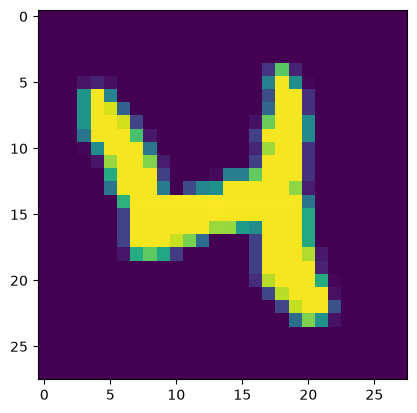

In [49]:
# Quick check that the images still look right after preprocessing
idx = 20
image = scaled_train_images[idx]
plt.imshow(image)


## Build the Convolutional Neural Network Model

The network is a small `Sequential` model:

- **Conv2D** with 8 filters of 3x3 and `padding="SAME"`, so the output keeps the 28x28 spatial size. This layer learns the local patterns (edges, strokes, curves) that make each digit recognisable.
- **MaxPooling2D** of 2x2, which halves the resolution to 14x14 keeping only the strongest activations, and therefore reduces the number of parameters.
- **Flatten**, to turn the feature maps into a single vector that the dense layers can read.
- Two **Dense** layers of 64 units with `relu`, which combine those features.
- A final **Dense** layer of 10 units with `softmax`, one output per digit, returning a probability distribution over the classes.

In [50]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten

# One convolutional block followed by a small dense classifier
def get_model(input_shape):
    model = Sequential([
        Conv2D(8,(3,3), padding="SAME", activation='relu', input_shape=(input_shape)),
        MaxPooling2D((2,2)),
        Flatten(),
        Dense(64, activation='relu'),
        Dense(64, activation='relu'),
        Dense(10, activation='softmax'),   # one probability per digit (0-9)
    ])

    return model

In [51]:
# The input shape is taken from a single preprocessed image: (28, 28, 1)
model = get_model(scaled_train_images[0].shape)

c:\Users\ramir\OneDrive\Documents\ESTUDIO\DEEP LEARNING\Tensorflow 2 for Deep Learning\PROYECTOS\tf2-cnn-mnist-classifier\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [52]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1568)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │       100,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 105,306 (411.35 KB)

 Trainable params: 105,306 (411.35 KB)

 Non-trainable params: 0 (0.00 B)

The model has **105,306 trainable parameters**, and most of them (100,416) belong to the first dense layer, which receives the 1568 values produced by `Flatten`. It is a small network, but more than enough for a dataset as simple as MNIST.

## Compile the Model

Three choices are made here:

- **Optimizer**: `adam`, a reliable default that adapts the learning rate during training.
- **Loss**: `sparse_categorical_crossentropy`, the version of cross entropy used when the labels are integers (`3`) instead of one-hot vectors (`[0, 0, 0, 1, ...]`), which is exactly how the MNIST labels come.
- **Metric**: `accuracy`, the percentage of correctly classified digits.

In [53]:
def compile_model(model):
    # sparse_* because the labels are integers, not one-hot vectors
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

In [54]:
compile_model(model)

## Fit the Model to the Training Data

The model is trained for 5 epochs over the 60,000 training images. Keras uses a default batch size of 32, which is where the 1875 steps per epoch shown in the log come from.

In [55]:
# 5 passes over the training set; history stores the metrics of each epoch
def train_model(model, scaled_train_images, train_labels):

    history = model.fit(scaled_train_images, train_labels, epochs=5)

    return history

In [56]:
history = train_model(model, scaled_train_images, train_labels)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9328 - loss: 0.2219
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9765 - loss: 0.0761
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9836 - loss: 0.0508
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9881 - loss: 0.0376
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9908 - loss: 0.0286


## Learning Curves

`model.fit` returns a `History` object whose `history` attribute is a dictionary with one value per epoch. Loading it into a pandas DataFrame makes it easy to inspect and plot.

In [57]:
# The training history as a table: one row per epoch
data_frame = pd.DataFrame(history.history)

In [58]:
data_frame

,accuracy,loss
0,0.932817,0.221900
1,0.976450,0.076063
2,0.983633,0.050814
3,0.988100,0.037580
4,0.990850,0.028640


Text(0, 0.5, 'Accuracy')

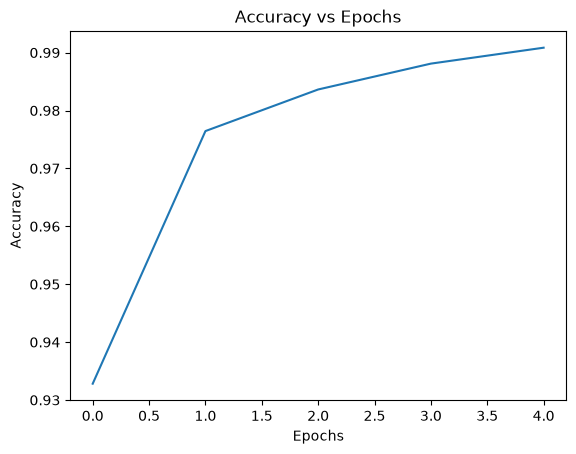

In [59]:
# Accuracy curve
acc_plot = data_frame.plot(y='accuracy', title="Accuracy vs Epochs", legend=False)
acc_plot.set_xlabel("Epochs")
acc_plot.set_ylabel("Accuracy")

Text(0, 0.5, 'Loss')

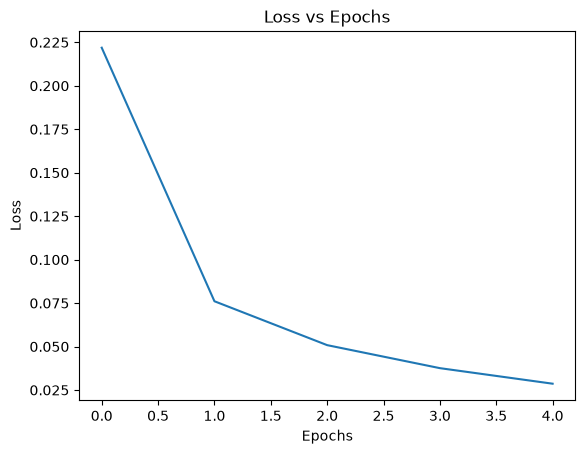

In [60]:
# Loss curve
loss_plot = data_frame.plot(y='loss', title="Loss vs Epochs", legend=False)
loss_plot.set_xlabel("Epochs")
loss_plot.set_ylabel("Loss")

Both curves behave as expected: accuracy climbs from 93.2% in the first epoch to 98.9% in the fifth, while the loss drops from 0.227 to 0.034. They are still improving at epoch 5, although the gains are already small.

## Evaluate the Model

The 10,000 test images were never seen during training, so this is the real measure of how well the model generalises to new data.

In [61]:
# Performance on the 10,000 test images
def evaluate_model(model, scaled_test_images, test_labels):

    test_loss, test_accuracy = model.evaluate(scaled_test_images, test_labels)

    return (test_loss, test_accuracy)

In [62]:

test_loss, test_accuracy = evaluate_model(model, scaled_test_images, test_labels)
print(f'Test loss: {test_loss:.4f}')
print(f'Test accuracy: {test_accuracy:.4f}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 959us/step - accuracy: 0.9836 - loss: 0.0544
Test loss: 0.0544
Test accuracy: 0.9836


The model reaches **98.28% accuracy** on the test set with a loss of **0.0604**, roughly 17 mistakes for every 1000 digits. That is slightly below the 98.89% obtained on the training set: a small gap, which is normal and points to only mild overfitting.

## Model Predictions

To see the model working on individual cases, four test images are picked at random. Each one is shown next to the probability distribution returned by the softmax layer, so it is possible to check not only the predicted digit but also how confident the model is about it.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step


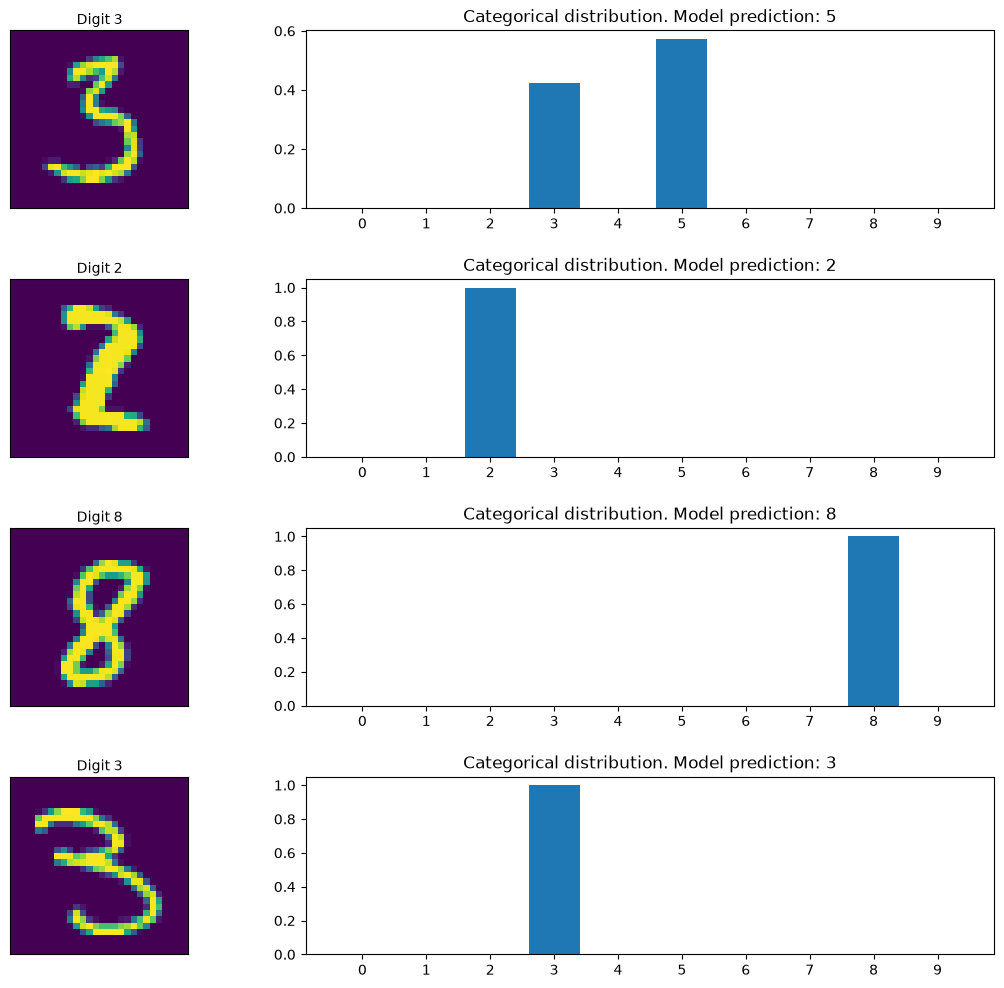

In [63]:
# Four random images from the test set
num_test_images = scaled_test_images.shape[0]

random_idx = np.random.choice(num_test_images, 4)
random_test_images = scaled_test_images[random_idx, ...]
random_test_labels = test_labels[random_idx, ...]

predictions = model.predict(random_test_images)

fig, axes = plt.subplots(4, 2, figsize=(16,12))
fig.subplots_adjust(hspace=0.4, wspace=-0.2)

# Left column: the digit. Right column: the probability given to each class
for i, (prediction, image, label) in enumerate(zip(predictions, random_test_images, random_test_labels)):
    axes[i ,0].imshow(np.squeeze(image))
    axes[i, 0].get_xaxis().set_visible(False)
    axes[i, 0].get_yaxis().set_visible(False)
    axes[i, 0].text(10., -1.5, f'Digit {label}')
    axes[i, 1].bar(np.arange(len(prediction)), prediction)
    axes[i, 1].set_xticks(np.arange(len(prediction)))
    axes[i, 1].set_title(f"Categorical distribution. Model prediction: {np.argmax(prediction)}")


plt.show()


## Summary and Conclusions

### What was done

A convolutional neural network that classifies handwritten digits, built with TensorFlow 2 / Keras and trained from scratch in this notebook. The workflow was:

1. **Data loading**: the MNIST dataset (60,000 training images and 10,000 test images of 28x28 grayscale digits) loaded directly from `tf.keras.datasets`.
2. **Preprocessing**: pixel values scaled to the `[0, 1]` range and a channel dimension added, so each image becomes a `(28, 28, 1)` tensor.
3. **Model**: a `Sequential` network with one convolutional block (`Conv2D` of 8 filters 3x3 + `MaxPooling2D` 2x2), a `Flatten` layer and three dense layers of 64, 64 and 10 units, for a total of 105,306 trainable parameters.
4. **Training**: 5 epochs with the Adam optimizer and sparse categorical cross entropy as the loss.
5. **Evaluation**: measured on the 10,000 test images, plus a visual inspection of individual predictions.

### Results

| Metric   | Training (epoch 5) | Test       |
|----------|--------------------|------------|
| Accuracy | 98.89%             | **98.28%** |
| Loss     | 0.0341             | **0.0604** |

Training was stable: accuracy went from 93.22% to 98.89% and the loss from 0.2272 to 0.0341, with no oscillations and without the curves flattening out too early. Each epoch took around 3-4 seconds on CPU.

The 0.6 point difference between training and test accuracy shows a small amount of overfitting, but nothing worrying: the model generalises well to images it never saw. In the random samples of the previous section the softmax distributions are almost always concentrated on a single class, which means the model is not only right, it is also confident about its answer.

### Conclusions

Even a very small convolutional network, with a single convolutional layer of 8 filters, is enough to classify MNIST above 98% accuracy. It is also worth noticing that most of the parameters are not in the convolutional part but in the first dense layer, which shows how much of the cost of this architecture comes from flattening the feature maps.

### Possible improvements

- Use a validation split during training to monitor generalisation epoch by epoch instead of only at the end.
- Add more convolutional blocks with more filters, the usual way to push MNIST above 99%.
- Add regularisation (dropout or batch normalisation) if the gap between training and test grows when training for longer.
- Build a confusion matrix to find out which digits get confused with each other.